# ِAbanoub Shenouda — CNN + Transfer Learning (VGG16)
## Cheating Detection in Exam Halls
---
**Input:** `processed_data/frames/`
```
Frames → tf.data → VGG16 (pretrained) → Train → Camera Test → Notification
```

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Cell 1 — Imports

In [4]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import VGG16
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import time
import os
import warnings
warnings.filterwarnings('ignore')

tf.random.set_seed(42)
np.random.seed(42)

## Cell 2 — Data Loading (tf.data.Dataset)

In [5]:
imgSize   = (224, 224)
batchSize = 64
EPOCHS     = 100

trainDir = '/content/drive/MyDrive/Cheating Video Recognition - Project/processed_data/frames/train'
testDir  = '/content/drive/MyDrive/Cheating Video Recognition - Project/processed_data/frames/test'
valDir   = '/content/drive/MyDrive/Cheating Video Recognition - Project/processed_data/frames/val'
os.makedirs('saved_vgg_model', exist_ok=True)

# ── Augmentation layer
augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.2),
    layers.RandomTranslation(0.1, 0.1),
], name='augmentation')

# ── tf.data.Dataset ────────────────────────────────────
train_ds = keras.utils.image_dataset_from_directory(
    trainDir,
    image_size=imgSize,
    batch_size=batchSize,
    label_mode='binary',
    shuffle=True,
    seed=42
)

val_ds = keras.utils.image_dataset_from_directory(
    valDir,
    image_size=imgSize,
    batch_size=batchSize,
    label_mode='binary',
    shuffle=False
)

test_ds = keras.utils.image_dataset_from_directory(
    testDir,
    image_size=imgSize,
    batch_size=batchSize,
    label_mode='binary',
    shuffle=False
)

CLASS_NAMES = train_ds.class_names
print('Classes:', CLASS_NAMES)

# ── Normalize + Augment + Prefetch
def preprocess_train(images, labels):
    images = tf.cast(images, tf.float32) / 255.0
    images = augmentation(images, training=True)
    return images, labels

def preprocess_eval(images, labels):
    images = tf.cast(images, tf.float32) / 255.0
    return images, labels

AUTOTUNE = tf.data.AUTOTUNE


train_ds = train_ds.cache().map(preprocess_train, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().map(preprocess_eval, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
test_ds  = test_ds.map(preprocess_eval,  num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

print('Train / Val / Test datasets ready')

Found 5165 files belonging to 2 classes.
Found 1086 files belonging to 2 classes.
Found 1173 files belonging to 2 classes.
Classes: ['cheating', 'normal']
Train / Val / Test datasets ready


## Cell 3 — Class Weights ( Imbalance)

In [6]:
all_labels = np.concatenate([y.numpy() for _, y in train_ds])

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(all_labels),
    y=all_labels.flatten()
)
class_weights = dict(enumerate(weights))

print('Class weights:', class_weights)
for i, name in enumerate(CLASS_NAMES):
    print(f'  {name}: {weights[i]:.3f}')

Class weights: {0: np.float64(0.6105200945626478), 1: np.float64(2.7620320855614975)}
  cheating: 0.611
  normal: 2.762


## Cell 4 — Build Model (VGG16)
```
VGG16 (pretrained ImageNet, frozen)
         ↓
GlobalAveragePooling2D
         ↓
Dense(256) → BatchNorm → ReLU → Dropout(0.5)
         ↓
Dense(128) → BatchNorm → ReLU → Dropout(0.3)
         ↓
Dense(1, sigmoid)
```

In [7]:
# ── VGG16 Base (frozen) ────────────────────────────────
base = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base.trainable = False

# ── Custom Head ────────────────────────────────────────
inputs = keras.Input(shape=(224, 224, 3))
x = base(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(256, kernel_regularizer=keras.regularizers.l2(0.001))(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Dropout(0.5)(x)

x = layers.Dense(128, kernel_regularizer=keras.regularizers.l2(0.001))(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(1, activation='sigmoid')(x)

model = keras.Model(inputs, outputs)

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,880,577 (56.76 MB)

 Trainable params: 165,121 (645.00 KB)

 Non-trainable params: 14,715,456 (56.14 MB)

## Cell 5 — Callbacks

In [8]:
callbacks = [

    keras.callbacks.ModelCheckpoint(
        'saved_models/best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=0
    ),

    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=0
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=7,
        min_lr=1e-7,
        verbose=0
    ),
]

## Cell 6 — Train

In [10]:
history = model.fit(
    train_ds,
    epochs=100,
    validation_data=val_ds,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 899ms/step - accuracy: 0.6126 - loss: 0.8896
Epoch 1: val_accuracy improved from 0.25322 to 0.77993, saving model to saved_models/best_model.keras

Epoch 1: finished saving model to saved_models/best_model.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 80s 973ms/step - accuracy: 0.6157 - loss: 0.8834 - val_accuracy: 0.7799 - val_loss: 0.8418 - learning_rate: 0.0010
Epoch 2/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 902ms/step - accuracy: 0.6402 - loss: 0.8732
Epoch 2: val_accuracy improved from 0.77993 to 0.87017, saving model to saved_models/best_model.keras

Epoch 2: finished saving model to saved_models/best_model.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 80s 977ms/step - accuracy: 0.6333 - loss: 0.8456 - val_accuracy: 0.8702 - val_loss: 0.7040 - learning_rate: 0.0010
Epoch 3/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 877ms/step - accuracy: 0.6801 - loss: 0.7900
Epoch 3: val_accuracy improved from 0.87017 to 0.91068, saving model to saved_models/best_model.keras

Epoch 3: finished 

## Cell 7 — Plot Training History

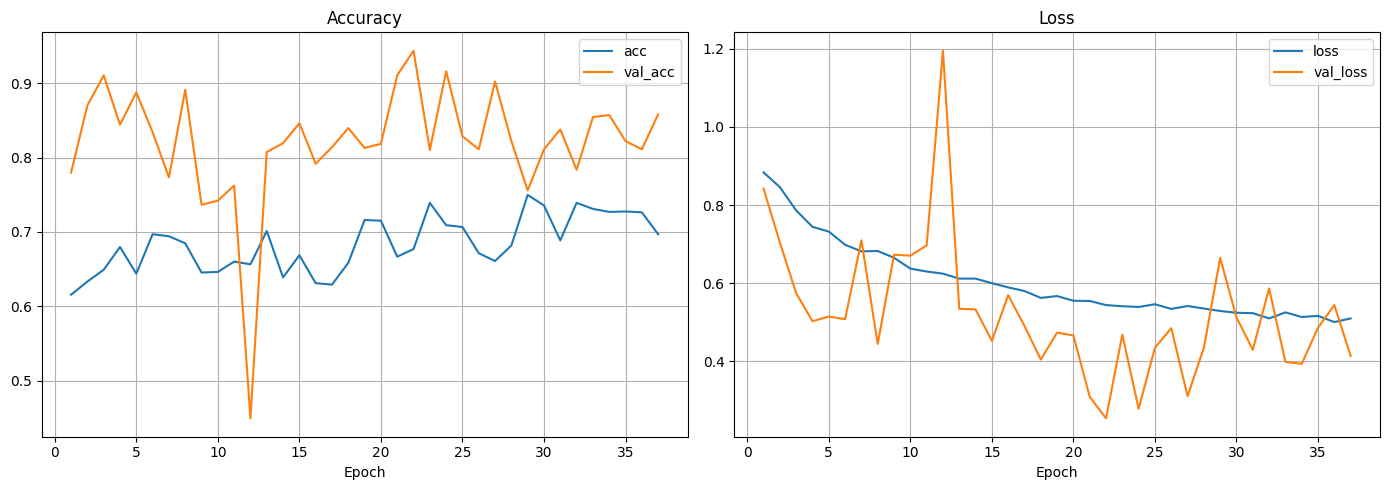

In [11]:
acc      = history.history['accuracy']
val_acc  = history.history['val_accuracy']
loss     = history.history['loss']
val_loss = history.history['val_loss']
epochs   = range(1, len(acc) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, acc,     label='acc')
axes[0].plot(epochs, val_acc, label='val_acc')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs, loss,     label='loss')
axes[1].plot(epochs, val_loss, label='val_loss')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('saved_models/training_curves.png', dpi=150)
plt.show()

## Cell 8 — Evaluate on Test Set

Test Loss     : 0.6540
Test Accuracy : 0.7852

Classification Report:
              precision    recall  f1-score   support

    cheating       0.86      0.87      0.87       934
      normal       0.47      0.45      0.46       239

    accuracy                           0.79      1173
   macro avg       0.67      0.66      0.66      1173
weighted avg       0.78      0.79      0.78      1173



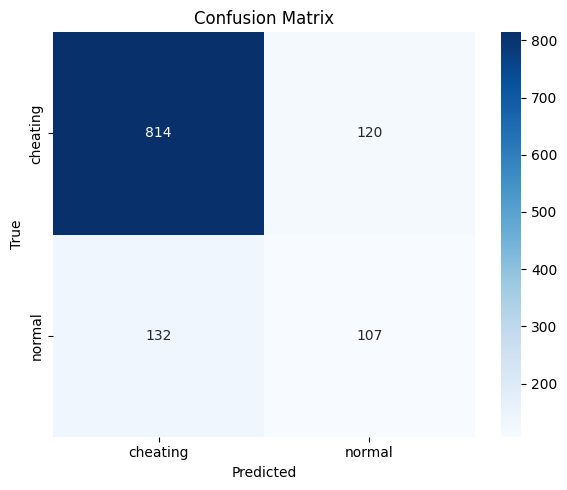

In [12]:
best_model = keras.models.load_model('saved_models/best_model.keras')

loss, acc = best_model.evaluate(test_ds, verbose=0)
print(f'Test Loss     : {loss:.4f}')
print(f'Test Accuracy : {acc:.4f}')

# Confusion Matrix
y_true, y_pred = [], []
for images, labels in test_ds:
    preds = best_model.predict(images, verbose=0)
    y_pred.extend((preds > 0.5).astype(int).flatten())
    y_true.extend(labels.numpy().flatten().astype(int))

print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('saved_models/confusion_matrix.png', dpi=150)
plt.show()

In [13]:
import os
import zipfile
from google.colab import files

folder_to_download = 'saved_models'
zip_filename = 'abanoub_cheating_detection_results.zip'

def zip_folder(folder_path, output_path):
    with zipfile.ZipFile(output_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files_list in os.walk(folder_path):
            for file in files_list:
                file_path = os.path.join(root, file)
                zipf.write(file_path, os.path.relpath(file_path, folder_path))

if os.path.exists(folder_to_download):
    zip_folder(folder_to_download, zip_filename)
    print(f"{folder_to_download}")

    files.download(zip_filename)
else:
    print(f"{folder_to_download} ")

تم ضغط المجلد: saved_models


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Cell 9 — Live Camera Test

بيفتح الكاميرا لمدة **30-40 ثانية**، بيعمل predict على كل frame، وفي الآخر بيبعت notification بالنتيجة.

**كاميرا الموبايل:**
1. حمّل تطبيق **IP Webcam** (Android) أو **EpocCam** (iPhone)
2. شغّل الـ app وهيديك رابط مثل: `http://192.168.1.5:8080/video`
3. حطّ الـ IP ده في `MOBILE_CAM_URL` تحت


In [16]:
import threading

# ── إعدادات الكاميرا ───────────────────────────────────
USE_LAPTOP_CAM  = True          # True = كاميرا اللاب
                                # False = كاميرا الموبايل
MOBILE_CAM_URL  = 'http://192.168.1.5:8080/video'  # ← غيّر الـ IP بتاعك
TEST_DURATION   = 35            # ثواني (30-40)
CHEAT_THRESHOLD = 0.5           # نسبة الـ cheating frames عشان يعتبره غش

# ── Notification بصوت + رسالة ──────────────────────────
def send_notification(result, cheat_ratio):
    msg = ''
    if result == 'CHEATING':
        msg = f'⚠️  تحذير: تم اكتشاف غش!  ({cheat_ratio:.0%} من الوقت)'
    else:
        msg = f'✅  لا يوجد غش  ({1 - cheat_ratio:.0%} طبيعي)'

    # رسالة على الشاشة
    print('\n' + '='*50)
    print(msg)
    print('='*50)

    # صوت تنبيه
    try:
        import winsound   # Windows
        if result == 'CHEATING':
            for _ in range(3):
                winsound.Beep(1000, 400)
                time.sleep(0.1)
        else:
            winsound.Beep(600, 500)
    except ImportError:
        try:
            import subprocess   # Mac / Linux
            if result == 'CHEATING':
                subprocess.run(['say', 'Warning cheating detected'], capture_output=True)
            else:
                subprocess.run(['say', 'No cheating detected'], capture_output=True)
        except:
            print('(تشغيل الصوت مش متاح على هذا النظام)')

# ── Predict على frame واحدة ────────────────────────────
def predict_frame(frame, loaded_model):
    img = cv2.resize(frame, imgSize)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img.astype(np.float32) / 255.0
    img = np.expand_dims(img, axis=0)
    prob = loaded_model.predict(img, verbose=0)[0][0]
    # CLASS_NAMES مرتبة أبجدياً: ['cheating'=0, 'normal'=1]
    label = CLASS_NAMES[int(prob > 0.5)]
    return label, prob

# ── Main Camera Loop ───────────────────────────────────
def run_camera_test():
    loaded_model = keras.models.load_model('saved_models/best_model.keras')

    # اختار مصدر الكاميرا
    if USE_LAPTOP_CAM:
        cap = cv2.VideoCapture(0)
        print('كاميرا اللاب شغالة...')
    else:
        cap = cv2.VideoCapture(MOBILE_CAM_URL)
        print(f'كاميرا الموبايل: {MOBILE_CAM_URL}')

    if not cap.isOpened():
        print('ERROR: مش قادر يفتح الكاميرا!')
        return

    print(f'\nالتسجيل بدأ — هينتهي بعد {TEST_DURATION} ثانية')
    print('اضغط Q للإيقاف المبكر')

    start_time    = time.time()
    total_frames  = 0
    cheat_frames  = 0
    predict_every = 10   # predict كل 10 frames عشان السرعة
    frame_count   = 0
    last_label    = 'normal'
    last_prob     = 0.0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        elapsed = time.time() - start_time
        remaining = TEST_DURATION - elapsed

        # Predict كل predict_every frames
        if frame_count % predict_every == 0:
            last_label, last_prob = predict_frame(frame, loaded_model)
            total_frames += 1
            if last_label == 'cheating':
                cheat_frames += 1

        # ── ارسم على الـ frame ──────────────────────────
        color = (0, 0, 255) if last_label == 'cheating' else (0, 200, 0)
        text  = f'{last_label.upper()}  ({last_prob:.0%})'
        cv2.rectangle(frame, (0, 0), (frame.shape[1], 50), (0, 0, 0), -1)
        cv2.putText(frame, text, (10, 35),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.0, color, 2)
        cv2.putText(frame, f'Time left: {remaining:.0f}s', (10, frame.shape[0] - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)

        cv2.imshow('Cheating Detection Test', frame)

        frame_count += 1

        # وقف لما الوقت خلص
        if elapsed >= TEST_DURATION:
            break

        # وقف لما اضغط Q
        if cv2.waitKey(1) & 0xFF == ord('q'):
            print('تم الإيقاف يدوياً')
            break

    cap.release()
    cv2.destroyAllWindows()

    # ── النتيجة النهائية ────────────────────────────────
    if total_frames == 0:
        print('لم يتم التقاط أي frames!')
        return

    cheat_ratio = cheat_frames / total_frames
    final_result = 'CHEATING' if cheat_ratio >= CHEAT_THRESHOLD else 'NORMAL'

    print(f'\nFrames analyzed : {total_frames}')
    print(f'Cheating frames : {cheat_frames} ({cheat_ratio:.0%})')

    send_notification(final_result, cheat_ratio)


# ── شغّل الـ test ──────────────────────────────────────
run_camera_test()

كاميرا اللاب شغالة...
ERROR: مش قادر يفتح الكاميرا!


In [20]:
# ============================================================
# إعدادات
# ============================================================
TEST_DURATION   = 35       # ثانية
CHEAT_THRESHOLD = 0.5      # لو أكتر من 50% من الـ frames غش → CHEATING
CAPTURE_EVERY   = 2        # صور frame كل كام ثانية
USE_MOBILE_CAM  = False    # True لو عايز كاميرا الموبايل بدل اللاب
MOBILE_CAM_URL  = 'http://192.168.1.5:8080/video'   # ← غيّر الـ IP بتاعك

IMG_SIZE        = (224, 224)
CLASS_NAMES     = ['cheating', 'normal']   # ترتيب أبجدي

# ============================================================
# Imports
# ============================================================
import numpy as np
import time
import base64
import cv2
from IPython.display import display, Javascript, HTML, clear_output
from google.colab.output import eval_js
from tensorflow import keras
import tensorflow as tf
import io
from PIL import Image
import ipywidgets as widgets
# ============================================================
# JavaScript — يصور frame من المتصفح
# ============================================================
CAPTURE_JS = """
async function captureFrame() {
    const stream = await navigator.mediaDevices.getUserMedia({video: true});
    const video  = document.createElement('video');
    video.srcObject = stream;
    await video.play();
    await new Promise(r => setTimeout(r, 500));
    const canvas = document.createElement('canvas');
    canvas.width  = video.videoWidth;
    canvas.height = video.videoHeight;
    canvas.getContext('2d').drawImage(video, 0, 0);
    stream.getTracks().forEach(t => t.stop());
    return canvas.toDataURL('image/jpeg', 0.85);
}
captureFrame();
"""

def capture_from_browser():
    b64 = eval_js(CAPTURE_JS)
    if ',' in b64:
        b64 = b64.split(',')[1]
    img_bytes = base64.b64decode(b64)
    np_arr    = np.frombuffer(img_bytes, np.uint8)
    frame     = cv2.imdecode(np_arr, cv2.IMREAD_COLOR)
    return frame

def capture_from_mobile():
    cap = cv2.VideoCapture(MOBILE_CAM_URL)
    ret, frame = cap.read()
    cap.release()
    return frame if ret else None

print('Capture functions ready')
#%%
# ============================================================
# Predict + تحديد نوع الغش
# ============================================================
def predict_frame(frame, loaded_model):
    """
    بيرجع:
      label      : 'cheating' أو 'normal'
      cheat_type : نوع الغش بناءً على تحليل الـ frame
      prob       : confidence
    """
    img = cv2.resize(frame, IMG_SIZE)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img.astype(np.float32) / 255.0
    img = np.expand_dims(img, axis=0)

    prob  = loaded_model.predict(img, verbose=0)[0][0]
    label = CLASS_NAMES[int(prob > 0.5)]

    # ── تحديد نوع الغش بناءً على تحليل بسيط للـ frame ──
    cheat_type = None
    if label == 'cheating':
        cheat_type = detect_cheat_type(frame)

    return label, cheat_type, float(prob)


def detect_cheat_type(frame):
    """
    بيحاول يعرف نوع الغش:
    - Phone Use  : لو فيه مستطيل صغير رأسي (شكل التليفون)
    - Looking    : لو الوجه مش في المنتصف (التفات)
    """
    h, w = frame.shape[:2]

    # ── 1. تحقق لو فيه تليفون (مستطيل رأسي صغير) ──────
    gray    = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    edges   = cv2.Canny(blurred, 50, 150)
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    for cnt in contours:
        x, y, cw, ch = cv2.boundingRect(cnt)
        area = cw * ch
        # التليفون: مستطيل رأسي مساحته معقولة
        if 2000 < area < (h * w * 0.15):
            ratio = ch / cw if cw > 0 else 0
            if 1.5 < ratio < 3.5:   # شكل التليفون
                return 'Phone Use'

    # ── 2. تحقق من التفات (وجه بعيد عن المنتصف) ────────
    face_cascade = cv2.CascadeClassifier(
        cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
    )
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)

    if len(faces) > 0:
        fx, fy, fw, fh = faces[0]
        face_center_x = fx + fw // 2
        frame_center_x = w // 2
        offset = abs(face_center_x - frame_center_x) / w   # 0 = مركز, 1 = أقصى الجانب
        if offset > 0.25:   # الوجه بعيد عن المنتصف بأكتر من 25%
            return 'Looking Sideways'

    return 'Suspicious Behavior'

print('Prediction functions ready')
#%%
# ============================================================
# رسم على الـ frame
# ============================================================
def draw_on_frame(frame, label, cheat_type, prob, remaining):
    out = frame.copy()
    h, w = out.shape[:2]

    is_cheat = (label == 'cheating')
    color     = (0, 0, 220)   if is_cheat else (0, 200, 0)
    bg_color  = (30, 0, 0)    if is_cheat else (0, 30, 0)

    # ── شريط علوي ────────────────────────────────────────
    cv2.rectangle(out, (0, 0), (w, 60), bg_color, -1)

    if is_cheat and cheat_type:
        status_text = f'CHEATING — {cheat_type}'
    elif is_cheat:
        status_text = 'CHEATING DETECTED'
    else:
        status_text = 'NORMAL'

    cv2.putText(out, status_text, (10, 38),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)
    cv2.putText(out, f'{prob:.0%}', (w - 80, 38),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)

    # ── شريط سفلي (الوقت المتبقي) ────────────────────────
    cv2.rectangle(out, (0, h - 35), (w, h), (20, 20, 20), -1)
    bar_w = int(w * remaining / TEST_DURATION)
    cv2.rectangle(out, (0, h - 35), (bar_w, h), (80, 80, 80), -1)
    cv2.putText(out, f'Time left: {remaining:.0f}s', (10, h - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.65, (200, 200, 200), 1)

    # ── لو غش: ارسم border أحمر ─────────────────────────
    if is_cheat:
        thickness = 6
        cv2.rectangle(out, (0, 0), (w, h), color, thickness)

        # ── ارسم label نوع الغش ─────────────────────────
        if cheat_type:
            tag_w, tag_h = 220, 36
            tag_x, tag_y = w // 2 - tag_w // 2, h // 2 - tag_h // 2
            cv2.rectangle(out, (tag_x, tag_y), (tag_x + tag_w, tag_y + tag_h),
                          (0, 0, 180), -1)
            cv2.rectangle(out, (tag_x, tag_y), (tag_x + tag_w, tag_y + tag_h),
                          (0, 0, 255), 2)
            cv2.putText(out, cheat_type, (tag_x + 10, tag_y + 24),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

    return out


def frame_to_jpeg_b64(frame):
    """يحول الـ frame لـ base64 عشان يعرضه في الـ notebook"""
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    pil_img   = Image.fromarray(frame_rgb)
    buffer    = io.BytesIO()
    pil_img.save(buffer, format='JPEG', quality=85)
    b64 = base64.b64encode(buffer.getvalue()).decode('utf-8')
    return b64

print('Drawing functions ready')
#%%
# ============================================================
# Notification
# ============================================================
def send_notification(result, cheat_ratio, cheat_types_count):

    if result == 'CHEATING':
        color = '#cc0000'
        icon  = '⚠️'
        msg   = f'تم اكتشاف غش! ({cheat_ratio:.0%} من الوقت)'

        # تفاصيل نوع الغش
        details = ''
        for ctype, count in cheat_types_count.items():
            details += f'<div style="margin:4px 0">• {ctype}: {count} مرة</div>'
    else:
        color   = '#007700'
        icon    = '✅'
        msg     = f'لا يوجد غش ({1 - cheat_ratio:.0%} طبيعي)'
        details = ''

    display(HTML(f"""
    <div style="background:{color}; color:white; padding:20px;
                border-radius:12px; font-size:20px; font-weight:bold;
                text-align:center; margin:10px;">
        {icon}&nbsp; {msg}
        <div style="font-size:15px; margin-top:10px; font-weight:normal">
            {details}
        </div>
    </div>
    """))

    # صوت تنبيه
    if result == 'CHEATING':
        display(Javascript("""
            var ctx = new AudioContext();
            [0, 0.5, 1.0].forEach(function(t) {
                var o = ctx.createOscillator();
                o.connect(ctx.destination);
                o.frequency.value = 1000;
                o.start(ctx.currentTime + t);
                o.stop(ctx.currentTime + t + 0.3);
            });
        """))
    else:
        display(Javascript("""
            var ctx = new AudioContext();
            var o = ctx.createOscillator();
            o.connect(ctx.destination);
            o.frequency.value = 600;
            o.start(); o.stop(ctx.currentTime + 0.5);
        """))

print('Notification function ready')
#%%
# ============================================================
# Main Camera Loop
# ============================================================
def run_camera_test():
    loaded_model = keras.models.load_model('saved_models/best_model.keras')
    print(f'Model loaded. بيصور لمدة {TEST_DURATION} ثانية...')
    print('اضغط على Stop Cell لو عايز توقف مبكراً')

    # Widget لعرض الـ frame
    img_widget = widgets.Image(format='jpeg', width=640)
    display(img_widget)

    start_time       = time.time()
    total_frames     = 0
    cheat_frames     = 0
    cheat_types_count = {}

    while True:
        elapsed   = time.time() - start_time
        remaining = TEST_DURATION - elapsed

        if elapsed >= TEST_DURATION:
            break

        # ── التقط frame ────────────────────────────────
        if USE_MOBILE_CAM:
            frame = capture_from_mobile()
        else:
            frame = capture_from_browser()

        if frame is None:
            print('فشل التقاط الـ frame — تأكد من الكاميرا')
            break

        # ── Predict ─────────────────────────────────────
        label, cheat_type, prob = predict_frame(frame, loaded_model)
        total_frames += 1

        if label == 'cheating':
            cheat_frames += 1
            if cheat_type:
                cheat_types_count[cheat_type] = cheat_types_count.get(cheat_type, 0) + 1

        # ── ارسم على الـ frame واعرضه ───────────────────
        annotated = draw_on_frame(frame, label, cheat_type, prob, remaining)
        img_widget.value = base64.b64decode(frame_to_jpeg_b64(annotated))

        time.sleep(CAPTURE_EVERY)

    # ── النتيجة النهائية ─────────────────────────────────
    if total_frames == 0:
        print('لم يتم التقاط أي frames!')
        return

    cheat_ratio  = cheat_frames / total_frames
    final_result = 'CHEATING' if cheat_ratio >= CHEAT_THRESHOLD else 'NORMAL'

    print(f'\nFrames analyzed : {total_frames}')
    print(f'Cheating frames : {cheat_frames} ({cheat_ratio:.0%})')
    if cheat_types_count:
        print(f'Cheat types     : {cheat_types_count}')

    send_notification(final_result, cheat_ratio, cheat_types_count)


run_camera_test()

Capture functions ready
Prediction functions ready
Drawing functions ready
Notification function ready
Model loaded. بيصور لمدة 35 ثانية...
اضغط على Stop Cell لو عايز توقف مبكراً


Image(value=b'', format='jpeg', width='640')


Frames analyzed : 10
Cheating frames : 5 (50%)
Cheat types     : {'Suspicious Behavior': 1, 'Phone Use': 4}


<IPython.core.display.Javascript object>